# pg_gpu Skills Demo

A linear walk-through of the pg_gpu API, mirroring how the Claude Code skill at `.claude/SKILL.md` translates natural-language asks into pg_gpu function calls. Each section has three parts: the prompt, the skill's plan, and the executed code (collapsed by default — click to expand) plus its output.

## Data

The outputs below come from Ag1000G Ag3.0 *Anopheles gambiae*, chromosome X: 1,470 diploids in a VCZ store on shared storage. The store and the sample metadata are named once, at the top of the first code cell.

To run this on your own data, point `DATA` at a directory holding a VCZ store plus a metadata CSV with a `sample_id` column. If the store is not there yet, the first cell builds it from a BCF.

<div class="user-prompt" markdown="1">

**User prompt:** `$>` Load this VCF, convert to zarr if needed, and import the first 10 Mb: `ag1000g.X.vcf.gz`

</div>

*Skill action:*

*1. If the zarr does not yet exist, call `HaplotypeMatrix.vcf_to_zarr(VCF_X, ZARR_X, worker_processes=24)` (one-time, ~hours on a 326 GB VCF).*
*2. Load 10 Mb with `HaplotypeMatrix.from_zarr(ZARR_X, region='X:1-10000000', streaming='auto')`.*
*3. `streaming='auto'` returns an eager `HaplotypeMatrix` if the materialized matrix fits in <50% of free GPU memory, otherwise a `StreamingHaplotypeMatrix`. All downstream stat functions accept either type.*


In [1]:
import os
import time
from pg_gpu import HaplotypeMatrix

# Ag1000G Ag3.0 gambiae X: 1,470 diploids. The VCZ store is on shared
# storage; see the note under "Data" for how to point this elsewhere.
DATA   = '/sietch_colab/ssmall/projects/pg_gpu_project/data'
VCF_X  = f'{DATA}/ag1000g.X.clean.bcf'
ZARR_X = f'{DATA}/ag1000g.X.clean.zarr'

t0 = time.time()

if not os.path.exists(ZARR_X):
    print('No zarr found -- converting')
    print(f'  src: {VCF_X}')
    print(f'  dst: {ZARR_X}')
    HaplotypeMatrix.vcf_to_zarr(VCF_X, ZARR_X, worker_processes=24)
    print(f'  conversion done in {time.time()-t0:.1f}s')
else:
    print(f'Using existing zarr: {ZARR_X}')

Using existing zarr: /sietch_colab/ssmall/projects/pg_gpu_project/data/ag1000g.X.clean.zarr


<div class="user-prompt" markdown="1">

**User prompt:** `$>` Run QC inspection on a 10 Mb region.

</div>

*Skill action:*

*1. `fields=` on `HaplotypeMatrix.from_zarr` is eager-only — raises `NotImplementedError` whenever the load takes the streaming path. For regions too big to fit (`streaming='auto'` falls back to streaming above 50% of free GPU memory), skip pg_gpu's loader.*
*2. Open the VCZ with `zarr.open(ZARR_X, mode='r')` and slice the `variant_<TAG>` / `call_<TAG>` arrays directly. They're plain zarr datasets; `[i0:i1]` returns numpy.*
*3. Find the variant index range for the region by scanning `variant_contig` and `variant_position`.*
*4. Read the per-variant arrays (`variant_MQ`, `variant_quality`) whole — one value per site.*
*5. Reduce the per-genotype arrays (`call_DP`, `call_GQ`) to per-site means a block of sites at a time on the GPU. `call_DP` over this region is 22 GB as int16, and a nan-aware host mean would expand it to float first — a block at a time keeps the footprint flat.*
*6. Build a per-site DataFrame with `MQ`, `quality`, `DP_mean`, `GQ_mean`, `missing_frac` for the downstream plots.*

In [2]:
import zarr
import numpy as np
import pandas as pd
import cupy as cp

CHROM, START, END = 'X', 1, 10_000_000

z = zarr.open(ZARR_X, mode='r')

# 1. Find the contiguous variant index range for the region.
t0         = time.time()
contig_ids = list(z['contig_id'][:])
ci         = contig_ids.index(CHROM)
mask       = ((z['variant_contig'][:] == ci) &
              (z['variant_position'][:] >= START) &
              (z['variant_position'][:] <= END))
idx        = np.where(mask)[0]
i0, i1     = int(idx.min()), int(idx.max()) + 1
print(f'{len(idx):,} variants in {CHROM}:{START:,}-{END:,}  (variant indices {i0:,}-{i1:,})')
print(f'  index lookup: {time.time() - t0:.1f}s')

# 2. Per-variant arrays hold one value per site, so they load whole.
t1      = time.time()
pos     = z['variant_position'][i0:i1]
mq      = z['variant_MQ'][i0:i1]
quality = z['variant_quality'][i0:i1]            # NOTE: literal key, not 'QUAL'
print(f'  per-variant reads: {time.time() - t1:.1f}s')


# 3. Reduce the per-genotype arrays a block of sites at a time on the GPU.
#    These are (n_var, n_samples): call_DP over 10 Mb is 22 GB as int16, and
#    expanding it to float on the host to get a nan-aware mean would cost
#    double that again. A block at a time keeps the footprint flat.
def per_site(name, block=50_000):
    """Return per-site mean over called genotypes, and missing fraction."""
    a      = z[name]
    n_var  = i1 - i0
    n_samp = a.shape[1]
    mean   = cp.empty(n_var, dtype=cp.float32)
    miss   = cp.empty(n_var, dtype=cp.float32)
    for lo in range(0, n_var, block):
        hi    = min(lo + block, n_var)
        blk   = cp.asarray(a[i0 + lo:i0 + hi])
        ok    = blk >= 0                          # -1 marks a missing call
        n     = ok.sum(axis=1)
        total = cp.where(ok, blk, 0).sum(axis=1, dtype=cp.int64)
        mean[lo:hi] = cp.where(n > 0, total / cp.maximum(n, 1), cp.nan)
        miss[lo:hi] = 1.0 - n / n_samp
    return cp.asnumpy(mean), cp.asnumpy(miss)


t2 = time.time()
dp_mean, dp_missing = per_site('call_DP')
gq_mean, _          = per_site('call_GQ')
dp = z['call_DP']
print(f'  genotype reductions: {time.time() - t2:.1f}s   '
      f'(call_DP alone is {(i1 - i0) * dp.shape[1] * dp.dtype.itemsize / 1e9:.2f} GB)')

site = pd.DataFrame({
    'pos':          pos,
    'MQ':           mq,
    'quality':      quality,
    'DP_mean':      dp_mean,
    'GQ_mean':      gq_mean,
    'missing_frac': dp_missing,
})
print(f'site: {len(site):,} rows x {site.shape[1]} cols')
site.describe(percentiles=[.01, .5, .99]).T.round(3)

7,610,314 variants in X:1-10,000,000  (variant indices 0-7,610,314)
  index lookup: 22.6s


  per-variant reads: 12.3s


  genotype reductions: 145.4s   (call_DP alone is 22.37 GB)


site: 7,610,314 rows x 6 cols


,count,mean,std,min,1%,50%,99%,max
pos,7610314.0,4928151.442,2900390.093,2.0,98310.130,4894508.500,9905511.870,1.000000e+07
MQ,7610314.0,59.836,1.781,0.0,54.240,60.000,61.290,6.866000e+01
quality,7610314.0,517.745,853.735,0.0,0.010,302.620,3923.620,1.025260e+04
DP_mean,7610314.0,33.006,4.388,7.0,24.871,33.074,38.915,2.500000e+02
GQ_mean,7610314.0,79.741,4.265,9.0,64.595,80.466,86.116,9.900000e+01
missing_frac,7610314.0,0.003,0.016,0.0,0.000,0.000,0.046,9.990000e-01


<div class="user-prompt" markdown="1">

**User prompt:** `$>` Flag anything that looks broken — constant fields, all-NaN fields, etc.

</div>

*Skill action:*

*1. Walk each column of the per-site DataFrame.*
*2. Compute `n_nan`, `n_unique` for each.*
*3. Flag as ALL-NaN, mostly-NaN (>90%), constant (1 unique), or low-cardinality (≤3 unique).*


In [3]:
# Skill action: walk every column, count NaN / unique values, flag constants,
# low-cardinality, and mostly-NaN fields.
def flag_columns(df):
    rows = []
    for c in df.columns:
        v = df[c].to_numpy().astype('f8')
        n_nan = int(np.isnan(v).sum())
        finite = v[~np.isnan(v)]
        n_unique = len(np.unique(finite))
        flag = ''
        if n_nan == len(v):
            flag = 'ALL-NaN'
        elif n_nan > 0.9 * len(v):
            flag = f'mostly-NaN ({n_nan/len(v):.0%})'
        elif n_unique == 1:
            flag = f'constant @ {finite[0]:.6g}'
        elif n_unique <= 3:
            flag = f'low-cardinality ({n_unique} unique)'
        rows.append((c, str(df[c].dtype), n_nan, n_unique, flag))
    return pd.DataFrame(rows, columns=['col', 'dtype', 'n_nan', 'n_unique', 'flag'])

flags = flag_columns(site)
flags

,col,dtype,n_nan,n_unique,flag
0,pos,int32,0,7610314,
1,MQ,float32,0,5175,
2,quality,float32,0,19222,
3,DP_mean,float32,0,595720,
4,GQ_mean,float32,0,668193,
5,missing_frac,float32,0,1224,


<div class="user-prompt" markdown="1">

**User prompt:** `$>` Show me bivariate plots of all quality metrics against each other.

</div>

*Skill action:*

*1. Drop columns flagged constant / all-NaN.*
*2. Render a lower-triangle hexbin matrix; diagonals are histograms.*
*3. Hexbin (not scatter) because there are ~10⁶ sites and scatter is unreadable past ~10⁴.*


Plotting: ['MQ', 'quality', 'DP_mean', 'GQ_mean', 'missing_frac']


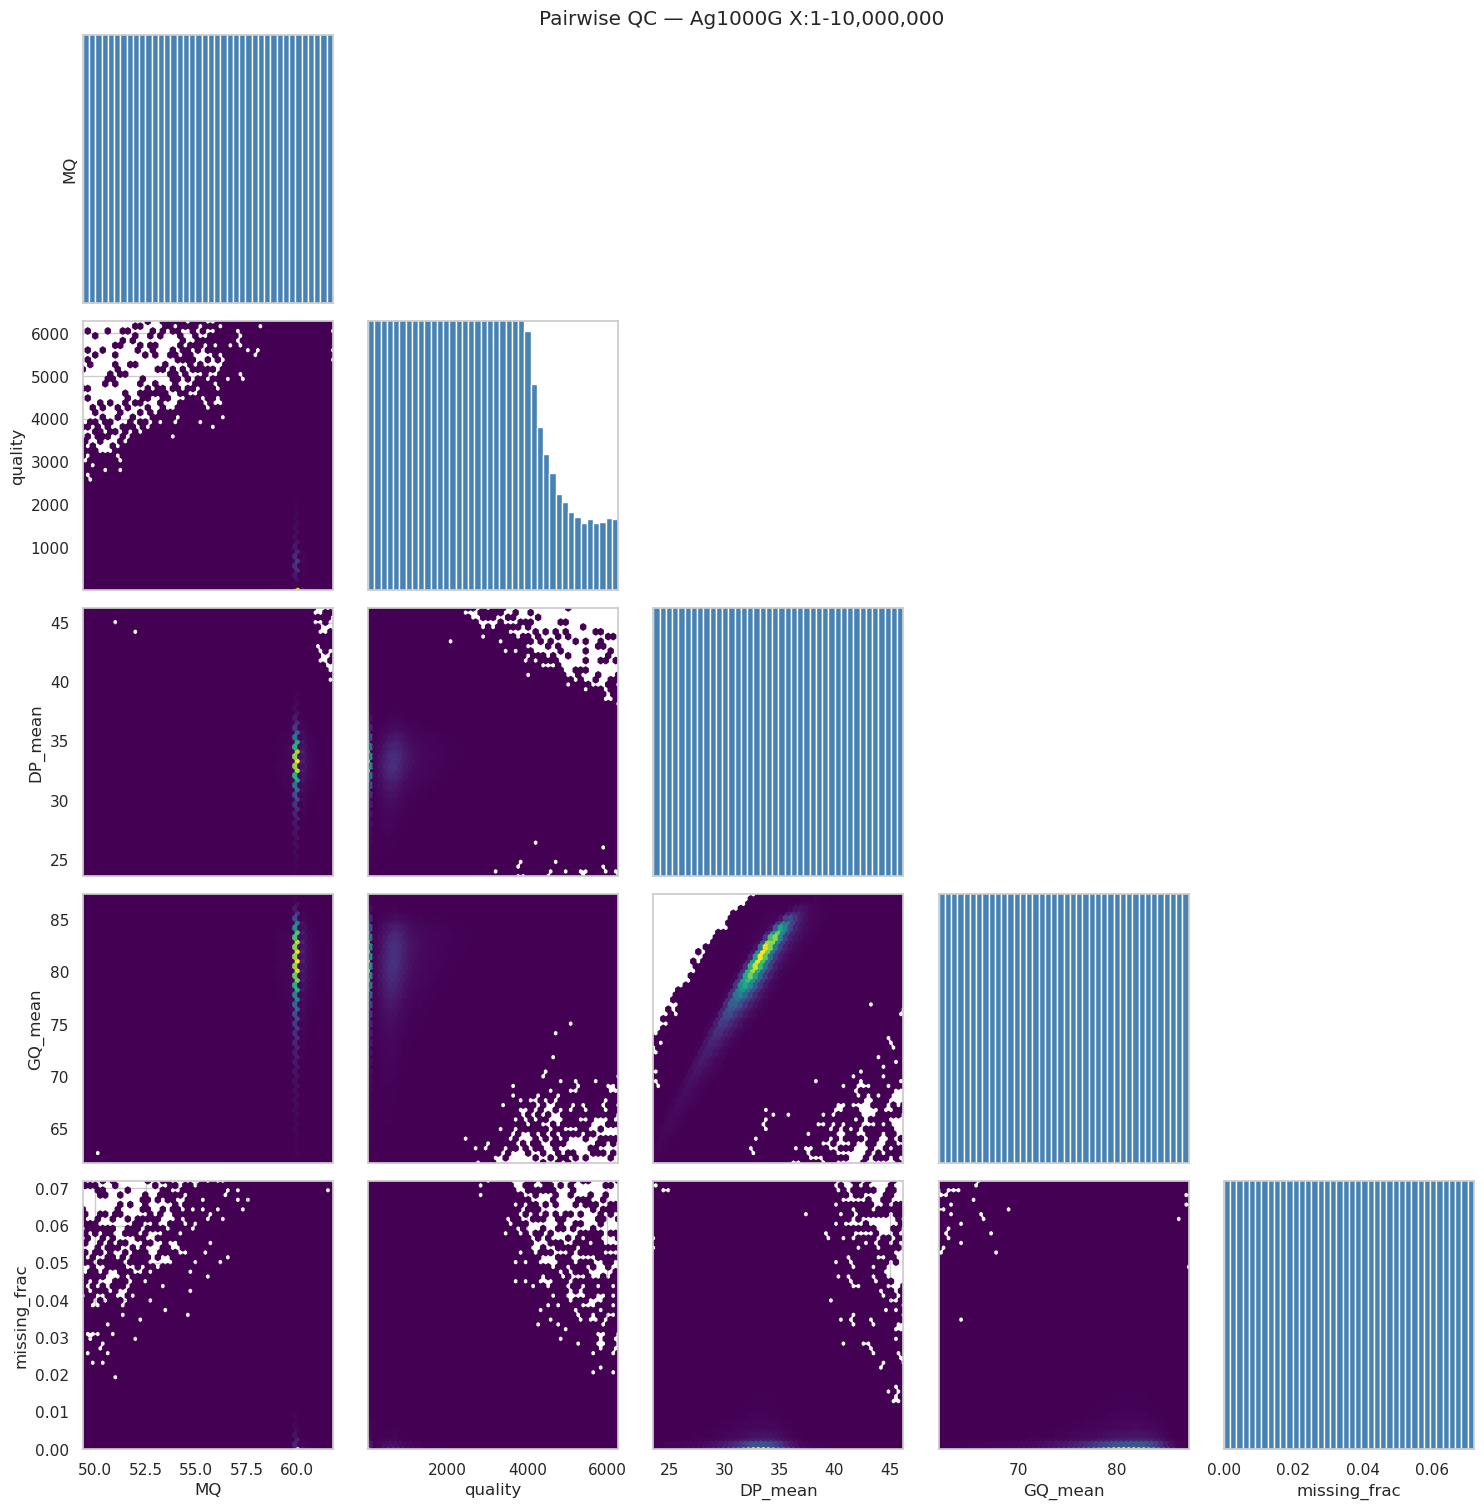

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='notebook', style='whitegrid')


# Skill action: lower-triangle hexbin matrix (scatter is unreadable past ~1e4
# points; hexbin handles 1e5-1e6 cleanly). Diagonal = histogram of each
# column. Constant / all-NaN fields dropped before plotting.
def pairwise_hexbin(df, cols, gridsize=50, figsize=None, q_clip=(0.005, 0.995)):
    n = len(cols)
    figsize = figsize or (3.0 * n, 3.0 * n)
    fig, axes = plt.subplots(n, n, figsize=figsize, squeeze=False)
    lims = {}
    for c in cols:
        v = df[c].to_numpy().astype('f8')
        lo, hi = np.nanquantile(v, q_clip)
        if lo == hi:
            lo, hi = lo - 0.5, hi + 0.5
        lims[c] = (lo, hi)
    for i, ci in enumerate(cols):
        for j, cj in enumerate(cols):
            ax = axes[i, j]
            if i == j:
                v = df[ci].to_numpy().astype('f8')
                m = np.isfinite(v) & (v >= lims[ci][0]) & (v <= lims[ci][1])
                ax.hist(v[m], bins=40, color='steelblue')
                ax.set_yticks([])
            elif j < i:
                x = df[cj].to_numpy().astype('f8')
                y = df[ci].to_numpy().astype('f8')
                m = np.isfinite(x) & np.isfinite(y)
                ax.hexbin(x[m], y[m], gridsize=gridsize, mincnt=1, extent=(*lims[cj], *lims[ci]), cmap='viridis')
            else:
                ax.set_visible(False)
            if i == n - 1:
                ax.set_xlabel(cj)
            else:
                ax.set_xticks([])
            if j == 0:
                ax.set_ylabel(ci)
            else:
                ax.set_yticks([])
            ax.set_xlim(*lims[cj])
            ax.set_ylim(*lims[ci])
    fig.tight_layout()
    return fig

drop = flags.set_index('col')
drop = drop[drop['flag'].str.startswith(('ALL-NaN', 'constant'))].index.tolist()
biv_cols = [c for c in site.columns if c != 'pos' and c not in drop]
print(f'Plotting: {biv_cols}')
if drop:
    print(f'Dropped (constant / all-NaN): {drop}')
fig = pairwise_hexbin(site, biv_cols)
fig.suptitle(f'Pairwise QC — Ag1000G {CHROM}:{START:,}-{END:,}', y=1.005)
plt.show()

<div class="user-prompt" markdown="1">

**User prompt:** `$>` Show me π calculated in 10,000 bp windows. What are my missingness options?

</div>

*Skill action:*

*1. `windowed_analysis(hm, window_size=10_000, step_size=10_000, statistics=['pi'], missing_data=mode)` for each mode.*
*2. Two `missing_data=` modes are implemented:*
*   - `'include'` (default) — keep every site, use per-site `n_valid` for the SFS counts; unbiased under MCAR.*
*   - `'exclude'` — drop any site that has a missing call before computing. A single missing call out of 1,470 samples removes the site, so this discards far more sites than the mean missing rate suggests.*
*3. For most analyses `'include'` is the right default; `'exclude'` is a sanity check — if the two diverge, missingness is structured and needs upstream investigation.*


hm: HaplotypeMatrix  variants=7,610,313  haps=2,940


include    windows=1000   median pi=0.007315   mean pi=0.007072


exclude    windows=1000   median pi=0.003184   mean pi=0.003136


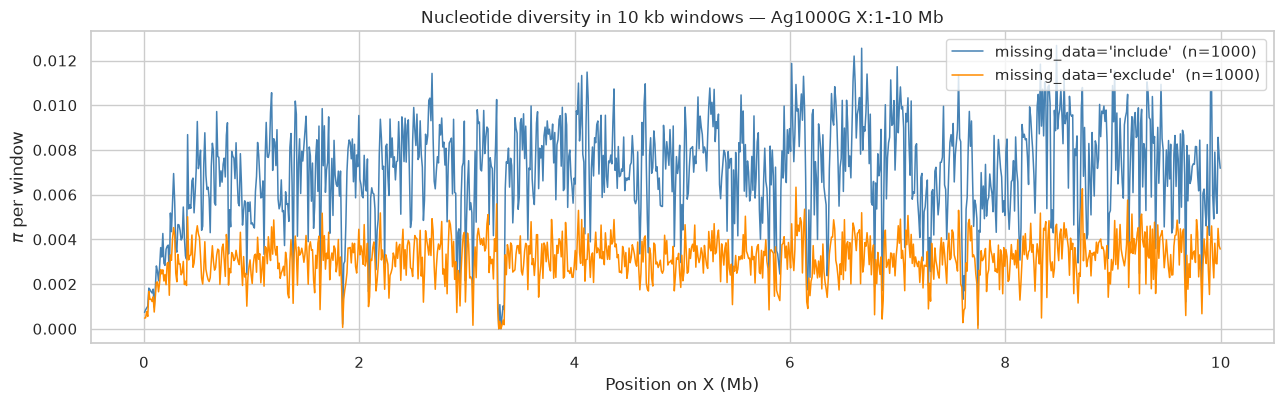

In [5]:
from pg_gpu import windowed_analysis

hm = HaplotypeMatrix.from_zarr(ZARR_X, region='X:1-10000000', streaming='auto')
print(f'hm: {type(hm).__name__}  variants={hm.num_variants:,}  haps={hm.num_haplotypes:,}')

results = {}
for mode in ['include', 'exclude']:
    results[mode] = windowed_analysis(
        hm, window_size=10_000, step_size=10_000,
        statistics=['pi'], missing_data=mode,
    )
    print(f"{mode:9s}  windows={len(results[mode]):4d}   "
          f"median pi={results[mode]['pi'].median():.6f}   "
          f"mean pi={results[mode]['pi'].mean():.6f}")

fig, ax = plt.subplots(figsize=(13, 4.2))
colors = {'include': 'steelblue', 'exclude': 'darkorange'}
for mode, df in results.items():
    ax.plot(df['center'] / 1e6, df['pi'], lw=1.1, color=colors[mode],
            label=f"missing_data='{mode}'  (n={len(df)})")
ax.set_xlabel('Position on X (Mb)')
ax.set_ylabel(r'$\pi$ per window')
ax.set_title('Nucleotide diversity in 10 kb windows — Ag1000G X:1-10 Mb')
ax.legend(loc='upper right', frameon=True)
plt.tight_layout(); plt.show()


<div class="user-prompt" markdown="1">

**User prompt:** `$>` Run a PCA and color the samples using the metadata file `ag1000g_metadata.csv`.

</div>

*Skill action:*

*1. `HaplotypeMatrix.from_zarr(region='X:1-2000000', streaming='never')` then `.restrict_to_biallelic()`. `pca` itself handles any number of alleles; the filter is here because the LD statistics are defined on biallelic sites.*
*2. Filter sites with **MAF > 0.05** — compute AF per site from `hm.haplotypes` (numpy), mask `-1` missing, drop monomorphic and rare. Subsumes 'segregating only'.*
*3. `hm.locate_unlinked(size=100, step=20, threshold=0.1)` → `get_subset()` — LD-prune so PCs reflect population structure, not LD blocks.*
*4. `decomposition.randomized_pca(hm, n_components=10)` — a faster approximation of `decomposition.pca`. Both take a `HaplotypeMatrix` and give one point per haplotype. For one point per individual instead, use `decomposition.pca_dosage` on a `GenotypeMatrix`.*
*5. Average per-haplotype coords to per-sample. **A sample's two haplotypes are adjacent** — sample `i` is at rows `2i` and `2i + 1`. Average: `(coords[0::2] + coords[1::2]) / 2`.*
*6. Merge with the metadata CSV on `sample_id`, scatter PC1 vs PC2 colored by `country`, `taxon`, `rdl_gt`.*


after biallelic filter: 1,256,734 variants


after MAF > 0.05:       4,257 common variants


after LD prune:         3,172 unlinked SNPs



PC variance explained (top 5): ['12.7%', '3.5%', '1.0%', '0.5%', '0.4%']


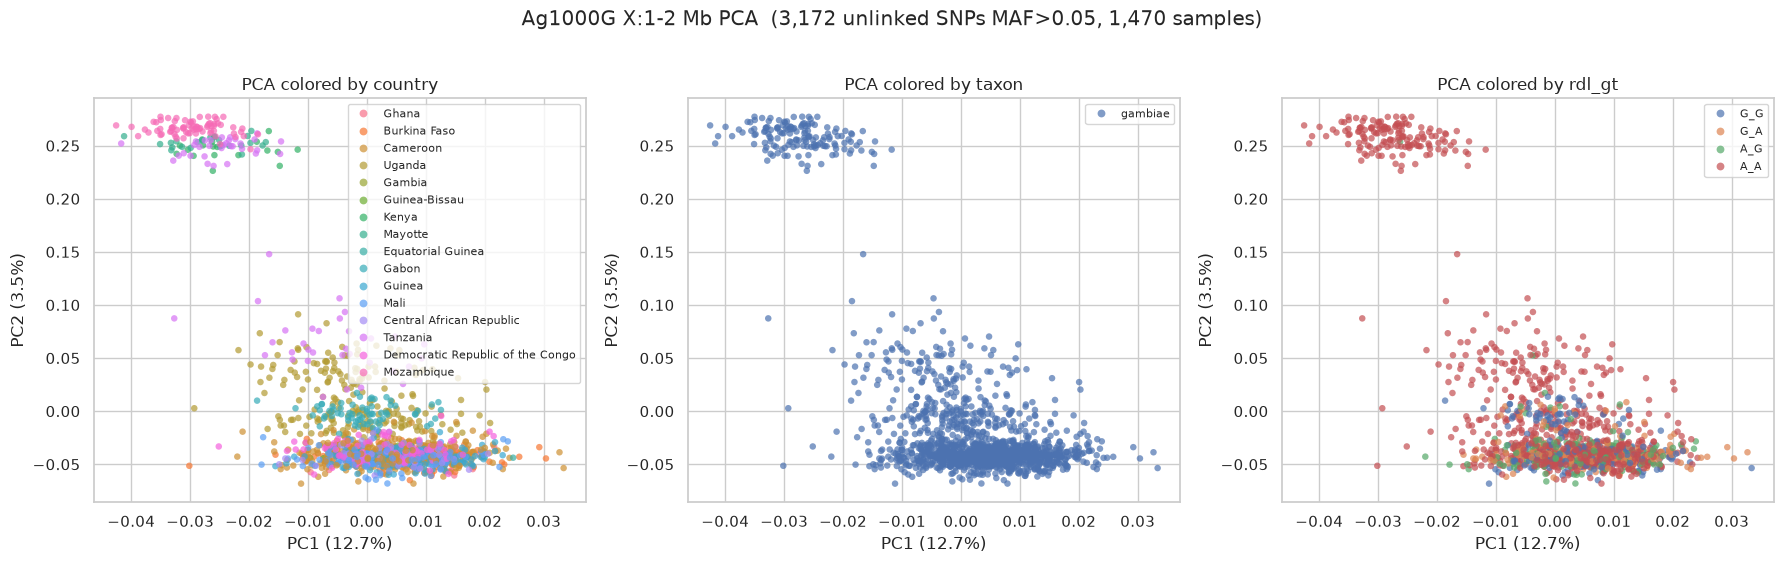

In [6]:
from pg_gpu import HaplotypeMatrix, decomposition
import zarr

META = ('/sietch_colab/data_share/Ag1000G/Ag3.0/sample_metadata/'
        'ag1kgp3.gamb.ck_short_sorted_rdl.csv')
meta = pd.read_csv(META)

z          = zarr.open(ZARR_X, mode='r')
sample_ids = list(z['sample_id'][:])
n_samples  = len(sample_ids)

# Load eagerly and biallelic-filter.
hm_raw = HaplotypeMatrix.from_zarr(ZARR_X, region='X:1-2000000', streaming='never')
hm_bi  = hm_raw.restrict_to_biallelic()
print(f'after biallelic filter: {hm_bi.num_variants:,} variants')

# MAF > 0.05. hm.haplotypes is a cupy array on a GPU-resident
# matrix; numpy ops below dispatch to cupy via NEP-18 so the math
# stays on the GPU. Convert with .get() only at the end.
haps    = hm_bi.haplotypes
n_valid = (haps >= 0).sum(axis=0)
alt     = (haps == 1).sum(axis=0)
af      = np.where(n_valid > 0, alt / np.maximum(n_valid, 1), 0.0)
maf     = np.minimum(af, 1.0 - af)
keep    = np.where(maf > 0.05)[0]
hm_common = hm_bi.get_subset(keep)
print(f'after MAF > 0.05:       {hm_common.num_variants:,} common variants')

# LD-prune.
unlinked = hm_common.locate_unlinked(size=100, step=20, threshold=0.1)
unlinked_np = unlinked.get() if hasattr(unlinked, 'get') else np.asarray(unlinked)
hm_pca   = hm_common.get_subset(np.where(unlinked_np)[0])
print(f'after LD prune:         {hm_pca.num_variants:,} unlinked SNPs')

# Randomized PCA.
coords, explained = decomposition.randomized_pca(hm_pca, n_components=10)
coords_np = coords.get() if hasattr(coords, 'get') else np.asarray(coords)
explained = explained.get() if hasattr(explained, 'get') else np.asarray(explained)

# pg_gpu layout: a sample's two haplotypes are adjacent, so sample i
# is at rows 2i and 2i + 1.
coords_per_sample = (coords_np[0::2] + coords_np[1::2]) / 2.0

df = pd.DataFrame(coords_per_sample, columns=[f'PC{i+1}' for i in range(coords_per_sample.shape[1])])
df['sample_id'] = sample_ids
df = df.merge(meta, on='sample_id', how='left')
print(f'\nPC variance explained (top 5): '
      f'{[f"{v*100:.1f}%" for v in explained[:5]]}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, hue in zip(axes, ['country', 'taxon', 'rdl_gt']):
    sns.scatterplot(data=df, x='PC1', y='PC2', hue=hue, ax=ax,
                    alpha=0.7, s=22, edgecolor='none')
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
    ax.set_title(f'PCA colored by {hue}')
    ax.legend(loc='best', fontsize=8, markerscale=1.2)
fig.suptitle(f'Ag1000G X:1-2 Mb PCA  ({hm_pca.num_variants:,} unlinked SNPs MAF>0.05, {n_samples:,} samples)', y=1.02)
plt.tight_layout(); plt.show()

# The 10 Mb matrix and the PCA intermediates are finished with. Dropping the
# references and returning the blocks to cupy's pool keeps the rest of the
# notebook inside one GPU -- the 10 Mb load alone is ~22 GB at 2,940 haplotypes.
import cupy as cp

for _name in ('hm', 'hm_raw', 'hm_bi', 'hm_common', 'hm_pca'):
    globals().pop(_name, None)
cp.get_default_memory_pool().free_all_blocks()
free, total = cp.cuda.Device().mem_info
print(f'GPU free after cleanup: {free/2**30:.0f} GiB of {total/2**30:.0f}')


<div class="user-prompt" markdown="1">

**User prompt:** `$>` Set up populations from the metadata so the rest of the stats can compare groups.

</div>

*Skill action:*

*1. Load a fresh 2 Mb biallelic matrix that the next several stat cells share: `HaplotypeMatrix.from_zarr(region='X:1-2000000', streaming='never').restrict_to_biallelic()`.*
*2. Map `country` in the metadata to haplotype indices. **A sample's two haplotypes are adjacent** — sample `i` is at rows `2i` and `2i + 1`. `load_pop_file` does this mapping for you when the matrix carries sample names.*
*3. Keep the top 4 most-sampled countries.*
*4. Attach as `hm_stats.sample_sets = {country: [hap_indices]}`.*


In [7]:
hm_stats = HaplotypeMatrix.from_zarr(ZARR_X, region='X:1-2000000', streaming='never')
hm_stats = hm_stats.restrict_to_biallelic()
print(f'hm_stats: {hm_stats.num_variants:,} biallelic variants x {hm_stats.num_haplotypes:,} haps')

n_samples = hm_stats.num_haplotypes // 2

# pg_gpu layout: a sample's two haplotypes are adjacent, so sample i
# is at rows 2i and 2i + 1.
sample_to_idx = {s: i for i, s in enumerate(sample_ids)}
country_to_haps = {}
for country, gdf in meta.groupby('country'):
    haps = []
    for s in gdf['sample_id']:
        if s in sample_to_idx:
            i = sample_to_idx[s]
            haps.extend([2 * i, 2 * i + 1])
    country_to_haps[country] = haps

top4 = sorted(country_to_haps, key=lambda k: -len(country_to_haps[k]))[:4]
hm_stats.sample_sets = {c: country_to_haps[c] for c in top4}
print('populations attached:')
for c, h in hm_stats.sample_sets.items():
    print(f'  {c:20s}  n_haps={len(h):,}  (n_diploids={len(h)//2})')


hm_stats: 1,256,734 biallelic variants x 2,940 haps
populations attached:
  Cameroon              n_haps=832  (n_diploids=416)
  Uganda                n_haps=414  (n_diploids=207)
  Burkina Faso          n_haps=314  (n_diploids=157)
  Mali                  n_haps=262  (n_diploids=131)


<div class="user-prompt" markdown="1">

**User prompt:** `$>` Compute diversity stats (π, θ_W, Tajima's D, expected heterozygosity) for each population in one shot.

</div>

*Skill action:*

*1. For each population in `hm_stats.sample_sets`, call `diversity.diversity_stats(hm_stats, population=pop, statistics=['pi','theta_w','theta_h','theta_l','tajimas_d'])`.*
*2. Single GPU pass per population — much cheaper than calling each function separately.*
*3. Tabulate per-pop into a DataFrame.*


In [8]:
from pg_gpu import diversity

rows = []
for pop in hm_stats.sample_sets:
    s = diversity.diversity_stats(
        hm_stats, population=pop,
        statistics=['pi', 'theta_w', 'theta_h', 'theta_l', 'tajimas_d'],
    )
    # Convert any CuPy scalars to plain floats.
    s = {k: float(v.get() if hasattr(v, 'get') else v) for k, v in s.items()}
    s['n_diploids'] = len(hm_stats.sample_sets[pop]) // 2
    rows.append({'pop': pop, **s})

div_df = pd.DataFrame(rows).set_index('pop')
div_df.round(5)

,theta_w,pi,theta_l,theta_h,tajimas_d,n_diploids
pop,,,,,,
Cameroon,0.02250,0.00285,0.00259,0.00233,-2.60077,416
Uganda,0.01315,0.00268,0.00244,0.00219,-2.45918,207
Burkina Faso,0.01596,0.00287,0.00254,0.00221,-2.57474,157
Mali,0.01291,0.00281,0.00249,0.00216,-2.48489,131


<div class="user-prompt" markdown="1">

**User prompt:** `$>` Plot the unfolded and folded site frequency spectrum for each population side-by-side.

</div>

*Skill action:*

*1. For each population: `sfs.sfs(hm_stats, population=pop)` for the unfolded spectrum, `sfs.sfs_folded(hm_stats, population=pop)` for the folded.*
*2. The unfolded spectrum has length `n_haps+1`; the folded one is about half that. Sites where nothing varies are already left out, so the first and last bins are zero and are sliced off only to tidy the plot.*
*3. Plot all populations on log-y axes — side-by-side panels.*


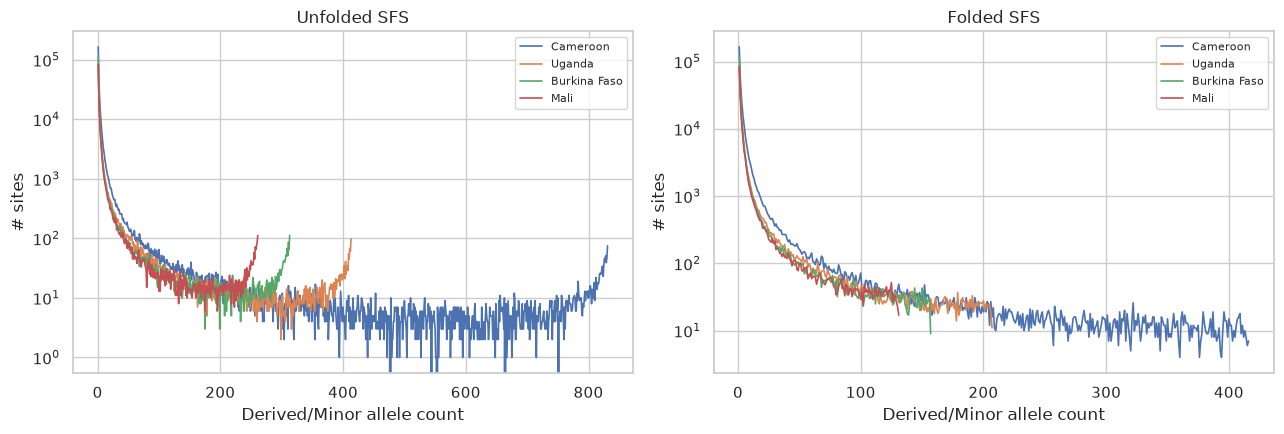

In [9]:
from pg_gpu import sfs as pg_sfs

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for pop in hm_stats.sample_sets:
    s_un = pg_sfs.sfs(hm_stats, population=pop)
    s_fo = pg_sfs.sfs_folded(hm_stats, population=pop)
    s_un = s_un.get() if hasattr(s_un, 'get') else np.asarray(s_un)
    s_fo = s_fo.get() if hasattr(s_fo, 'get') else np.asarray(s_fo)
    # Trim the always-zero end bins so the log axis looks clean.
    axes[0].plot(np.arange(1, len(s_un)-1), s_un[1:-1], label=pop, lw=1.2)
    axes[1].plot(np.arange(1, len(s_fo)),   s_fo[1:],   label=pop, lw=1.2)
for ax, title in zip(axes, ['Unfolded SFS', 'Folded SFS']):
    ax.set_yscale('log'); ax.set_xlabel('Derived/Minor allele count')
    ax.set_ylabel('# sites'); ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

<div class="user-prompt" markdown="1">

**User prompt:** `$>` Compute pairwise FST and dxy between every population pair.

</div>

*Skill action:*

*1. For each `(p1, p2)` in `itertools.combinations(pops, 2)`: `divergence.fst(hm_stats, p1, p2)` (Hudson FST by default) and `divergence.dxy(hm_stats, p1, p2)`.*
*2. Tabulate into a long-form DataFrame, pivot to a symmetric matrix.*
*3. Render as two heatmaps side-by-side.*


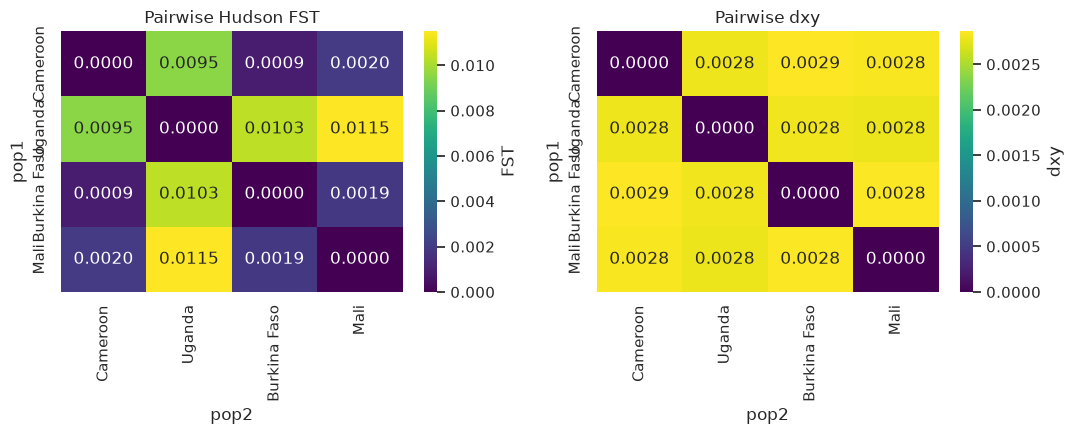

,pop1,pop2,fst,dxy
0,Cameroon,Uganda,0.00949,0.00279
1,Cameroon,Burkina Faso,0.00086,0.00286
2,Cameroon,Mali,0.00200,0.00284
3,Uganda,Burkina Faso,0.01034,0.00281
4,Uganda,Mali,0.01150,0.00278
5,Burkina Faso,Mali,0.00186,0.00285


In [10]:
from pg_gpu import divergence
from itertools import combinations

pops = list(hm_stats.sample_sets)
rows = []
for p1, p2 in combinations(pops, 2):
    fst = divergence.fst(hm_stats, p1, p2)
    dxy = divergence.dxy(hm_stats, p1, p2)
    rows.append({'pop1': p1, 'pop2': p2,
                 'fst':  float(fst.get() if hasattr(fst, 'get') else fst),
                 'dxy':  float(dxy.get() if hasattr(dxy, 'get') else dxy)})
pairwise = pd.DataFrame(rows)

# Build symmetric matrices for a quick visual.
fst_mat = pairwise.pivot(index='pop1', columns='pop2', values='fst').reindex(index=pops, columns=pops)
fst_mat = fst_mat.fillna(0) + fst_mat.fillna(0).T
dxy_mat = pairwise.pivot(index='pop1', columns='pop2', values='dxy').reindex(index=pops, columns=pops)
dxy_mat = dxy_mat.fillna(0) + dxy_mat.fillna(0).T

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(fst_mat, annot=True, fmt='.4f', cmap='viridis', ax=axes[0],
            cbar_kws={'label': 'FST'})
sns.heatmap(dxy_mat, annot=True, fmt='.4f', cmap='viridis', ax=axes[1],
            cbar_kws={'label': 'dxy'})
axes[0].set_title('Pairwise Hudson FST'); axes[1].set_title('Pairwise dxy')
plt.tight_layout(); plt.show()
pairwise.round(5)

<div class="user-prompt" markdown="1">

**User prompt:** `$>` Run windowed FST and dxy across the 2 Mb region for one population pair.

</div>

*Skill action:*

*1. Pick the most-diverged pair from the previous heatmap (highest FST).*
*2. Single GPU pass: `windowed_analysis(hm_stats, window_size=10_000, step_size=10_000, statistics=['fst','dxy'], populations=[p1, p2], missing_data='include')`.*
*3. Plot FST and dxy across the region in two stacked panels sharing the X axis.*


windowed FST/dxy: Uganda vs Mali


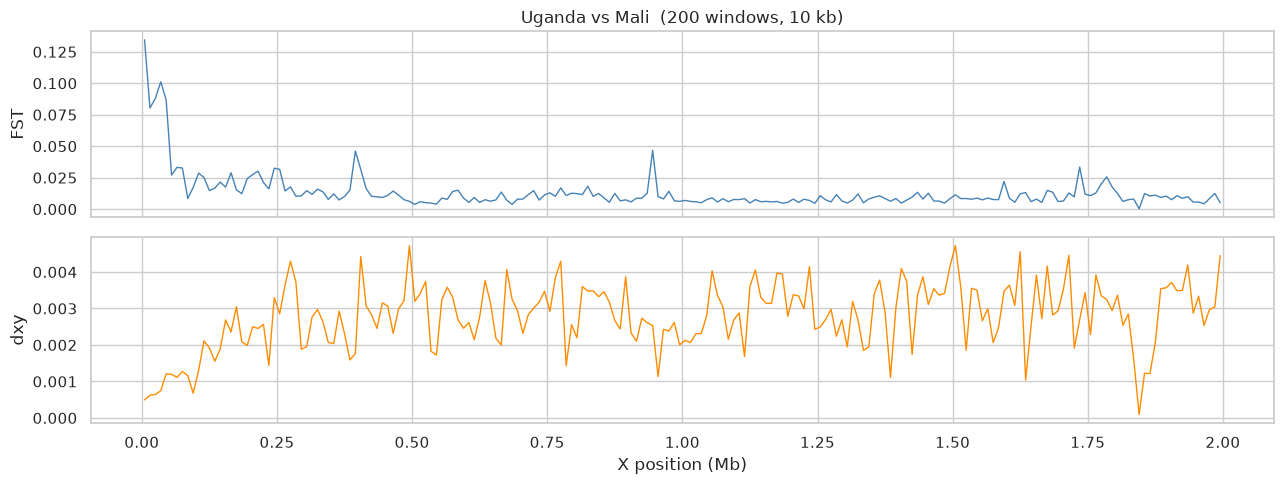

In [11]:
from pg_gpu import windowed_analysis

# Most diverged pair (max FST) from the previous step.
p1, p2 = pairwise.sort_values('fst', ascending=False).iloc[0][['pop1', 'pop2']]
print(f'windowed FST/dxy: {p1} vs {p2}')

wdf = windowed_analysis(
    hm_stats, window_size=10_000, step_size=10_000,
    statistics=['fst', 'dxy'],
    populations=[p1, p2],
    missing_data='include',
)
fst_col = next(c for c in wdf.columns if c.startswith('fst'))
dxy_col = next(c for c in wdf.columns if c.startswith('dxy'))

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].plot(wdf['center']/1e6, wdf[fst_col], lw=1, color='steelblue')
axes[0].set_ylabel('FST'); axes[0].set_title(f'{p1} vs {p2}  ({len(wdf)} windows, 10 kb)')
axes[1].plot(wdf['center']/1e6, wdf[dxy_col], lw=1, color='darkorange')
axes[1].set_ylabel('dxy'); axes[1].set_xlabel('X position (Mb)')
plt.tight_layout(); plt.show()


<div class="user-prompt" markdown="1">

**User prompt:** `$>` Run a selection scan (iHS + Garud's H) on the largest population.

</div>

*Skill action:*

*1. iHS and Garud's H are **single-population** statistics; pass `population=pop` per population, otherwise the scan mixes all four into one (rarely informative).*
*2. `selection.ihs(hm_stats, population=pop)` returns per-site iHS scores (shape `(n_variants,)`); `selection.garud_h(...)` returns four **scalars** `(h1, h12, h123, h2_h1)` — for a position-vs-statistic curve use `windowed_analysis(statistics=['garud_h12'], populations=[pop])`.*
*3. pg_gpu does not inspect or enforce phase — it treats every VCF `GT` as two haplotypes regardless of `/` vs `|`. iHS / Garud are only meaningful when the input is statistically phased upstream (Ag1000G Ag3.0 is SHAPEIT-phased, so the assumption holds).*
*4. Plot |iHS| (per-site) and H12 (per-window) for the largest population.*


In [12]:
from pg_gpu import selection

biggest = max(hm_stats.sample_sets, key=lambda k: len(hm_stats.sample_sets[k]))
print(f'selection scans (per-pop) for plotting: {biggest} '
      f'(n_haps={len(hm_stats.sample_sets[biggest])})')

# Per-population iHS (per-site scores).
ihs_arr = selection.ihs(hm_stats, population=biggest)
ihs = ihs_arr.get() if hasattr(ihs_arr, 'get') else np.asarray(ihs_arr)

# Per-population windowed Garud's H12 (selection.garud_h returns SCALARS;
# for a position-vs-statistic plot use the windowed variant instead).
h12_df = windowed_analysis(
    hm_stats, window_size=10_000, step_size=10_000,
    statistics=['garud_h12'], populations=[biggest],
)
h12_col = next(c for c in h12_df.columns if c.startswith('garud_h12'))

pos = hm_stats.positions
if hasattr(pos, 'get'): pos = pos.get()

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
valid = np.isfinite(ihs)
axes[0].scatter(pos[valid]/1e6, np.abs(ihs[valid]), s=2, alpha=0.4, color='steelblue')
axes[0].set_ylabel('|iHS|'); axes[0].set_title(f'iHS  ({biggest})')

axes[1].plot(h12_df['center']/1e6, h12_df[h12_col], lw=0.8, color='seagreen')
axes[1].set_ylabel("Garud's H12 (10 kb windows)"); axes[1].set_xlabel('X position (Mb)')
plt.tight_layout(); plt.show()


selection scans (per-pop) for plotting: Cameroon (n_haps=832)


OutOfMemoryError: Out of memory allocating 8,364,828,160 bytes (allocated so far: 83,852,604,928 bytes).

<div class="user-prompt" markdown="1">

**User prompt:** `$>` Compute the proper 2-locus LD statistics (D², Dz, π_2) binned by bp distance — the moments-LD curves used for demographic inference.

</div>

*Skill action:*

*1. moments-LD is O(n_var²) per pop per pair per bin. Restrict to a smaller region and two populations so this finishes in minutes, not hours.*
*2. Load fresh 500 kb biallelic: `HaplotypeMatrix.from_zarr(region='X:1-500000', streaming='never').restrict_to_biallelic()`. Reuse the top-2 populations from `hm_stats.sample_sets`.*
*3. `from pg_gpu.moments_ld import compute_ld_statistics; compute_ld_statistics(haplotype_matrix=hm_ld, pop_assignment=..., pops=..., bp_bins=np.logspace(2,5,10).astype(int))`.*
*4. Output structure: `ld_stats['stats'] = [ld_names, het_names]`; `ld_stats['sums'] = [bin1_LD, bin2_LD, ..., het_sums]` — last entry has a different shape (the het summary).*
*5. Filter `sums` to LD-shaped arrays only, stack to `(n_bins, n_ld_stats)`, plot the within-population curves `DD_i_i`, `Dz_i_i_i`, `pi2_i_i_i_i`.*


In [13]:
from pg_gpu import moments_ld, ld_statistics

# moments-LD is O(n_var^2) per pop / per pair / per bin -- on the full
# 2 Mb biallelic matrix (~240k variants) it takes ~20 min even with two
# populations. For a demo that finishes in minutes, drop to a fresh
# 500 kb biallelic load and the top-two populations.
hm_ld = (HaplotypeMatrix
         .from_zarr(ZARR_X, region='X:1-500000', streaming='never')
         .restrict_to_biallelic())
ld_pops = list(hm_stats.sample_sets)[:2]
hm_ld.sample_sets = {p: hm_stats.sample_sets[p] for p in ld_pops}
print(f'hm_ld: {hm_ld.num_variants:,} biallelic variants  /  pops: {ld_pops}')

bp_bins = np.logspace(2, 5, 10).astype(int)
ld_stats = moments_ld.compute_ld_statistics(
    haplotype_matrix=hm_ld,
    pop_assignment={p: hm_ld.sample_sets[p] for p in ld_pops},
    pops=ld_pops,
    bp_bins=bp_bins,
    report=False,
)

# moments-LD output structure:
#   ld_stats['stats'] = [ld_names, het_names]    (two lists)
#   ld_stats['sums']  = [bin1_ld, bin2_ld, ..., binN_ld, het_sums]
#     The first N entries are per-bp-bin LD stats (shape == len(ld_names));
#     the last entry is the het summary (shape == len(het_names)).
ld_names  = list(ld_stats['stats'][0])
het_names = list(ld_stats['stats'][1])
n_ld      = len(ld_names)

ld_arrays = [np.asarray(a) for a in ld_stats['sums']
             if np.asarray(a).ndim == 1 and len(np.asarray(a)) == n_ld]
sums_per_bin = np.stack(ld_arrays)                                    # (n_bins, n_ld)
print(f'output: {sums_per_bin.shape[0]} LD-stat bins x {sums_per_bin.shape[1]} stats')
print(f'  first 6 stat names: {ld_names[:6]}')

bin_centers = np.sqrt(bp_bins[:-1] * bp_bins[1:])
sums_per_bin = sums_per_bin[: len(bin_centers)]

def curve(stat_name):
    if stat_name not in ld_names:
        return None
    return sums_per_bin[:, ld_names.index(stat_name)]

# Plot within-population D², Dz, pi2 for each population. Suffix _i_j(_k_l)
# convention: DD_i_i = within-pop i; Dz_i_i_i and pi2_i_i_i_i likewise.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)
stat_specs = [
    ('DD',  [f'DD_{i}_{i}'           for i in range(len(ld_pops))]),
    ('Dz',  [f'Dz_{i}_{i}_{i}'       for i in range(len(ld_pops))]),
    ('pi2', [f'pi2_{i}_{i}_{i}_{i}'  for i in range(len(ld_pops))]),
]
for ax, (title, keys) in zip(axes, stat_specs):
    plotted = False
    for i, k in enumerate(keys):
        y = curve(k)
        if y is None:
            continue
        ax.plot(bin_centers, y, marker='o', lw=1.0, label=ld_pops[i])
        plotted = True
    if not plotted:
        ax.text(0.5, 0.5, f'no {title} stats matched', ha='center', va='center',
                transform=ax.transAxes); ax.set_xticks([]); ax.set_yticks([])
        continue
    ax.set_xscale('log'); ax.set_xlabel('Pair separation (bp)')
    ylab = r'$\langle \pi_2 \rangle$' if title == 'pi2' else fr'$\langle {title} \rangle$'
    ax.set_title(title); ax.set_ylabel(ylab); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Reference scalar for context, computed on the full 2 Mb matrix.
zns = ld_statistics.zns(hm_stats)
zns = float(zns.get() if hasattr(zns, 'get') else zns)
print(f'\nReference: ZnS (mean pairwise r^2 over the 2 Mb hm_stats) = {zns:.4f}')

MemoryError: streaming='never' but the full matrix would be 1.3 GB on a device with 0.6 GB free (limit: 50%). Use streaming='auto' or 'always' to return a StreamingHaplotypeMatrix instead.

<div class="user-prompt" markdown="1">

**User prompt:** `$>` Give me a block-jackknife confidence interval on π for the largest population.

</div>

*Skill action:*

*1. `resampling.block_jackknife` operates on **pre-binned per-block values** — it does not take a HaplotypeMatrix and has no `block_size=` kwarg.*
*2. First compute per-block π in non-overlapping windows of the block size you want: `windowed_analysis(hm_stats, window_size=200_000, step_size=200_000, statistics=['pi'], populations=[pop])`.*
*3. Extract the per-window π array, pass through `resampling.block_jackknife(pi_per_block, statistic=lambda v: np.mean(v))` → `(estimate, se, _)`.*
*4. Approximate normal-theory 95% CI: `estimate ± 1.96 × se`.*
*5. 200 kb is reasonable for taxa with ~kb-scale LD decay; tune from the LD-decay panel above.*


In [14]:
from pg_gpu import resampling

biggest = max(hm_stats.sample_sets, key=lambda k: len(hm_stats.sample_sets[k]))

# Per-block pi at 200 kb resolution.
df_blocks = windowed_analysis(
    hm_stats, window_size=200_000, step_size=200_000,
    statistics=['pi'], populations=[biggest],
)
pi_col = next(c for c in df_blocks.columns if c.startswith('pi'))
pi_per_block = df_blocks[pi_col].to_numpy()
print(f'{len(pi_per_block)} blocks of 200 kb for population {biggest!r}')

pi_est, pi_se, _ = resampling.block_jackknife(
    pi_per_block,
    statistic=lambda v: float(np.mean(v)),
)
pi_est = float(pi_est); pi_se = float(pi_se)
ci_lo, ci_hi = pi_est - 1.96 * pi_se, pi_est + 1.96 * pi_se

print(f'pi ({biggest}):  estimate = {pi_est:.6f}')
print(f'               SE        = {pi_se:.6f}')
print(f'               95% CI    = [{ci_lo:.6f}, {ci_hi:.6f}]')


10 blocks of 200 kb for population 'Cameroon'
pi (Cameroon):  estimate = 0.002845
               SE        = 0.000158
               95% CI    = [0.002535, 0.003156]
